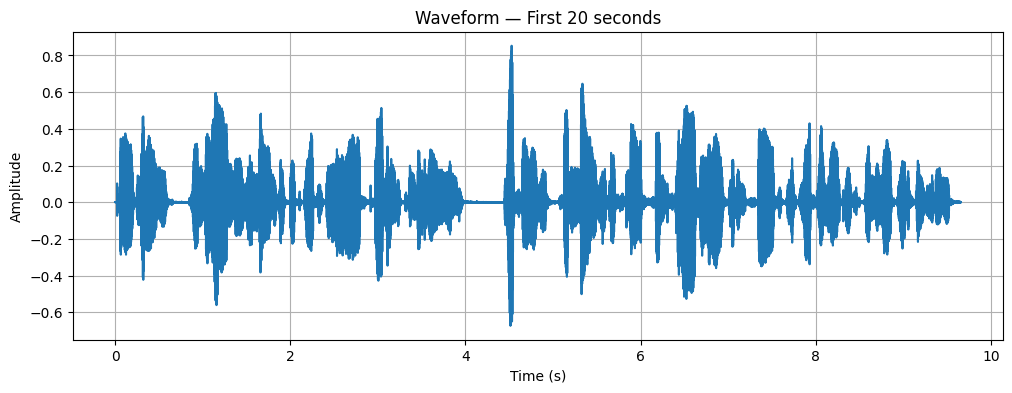

Frame length: 400
Frame shift: 160
Total frames: 964


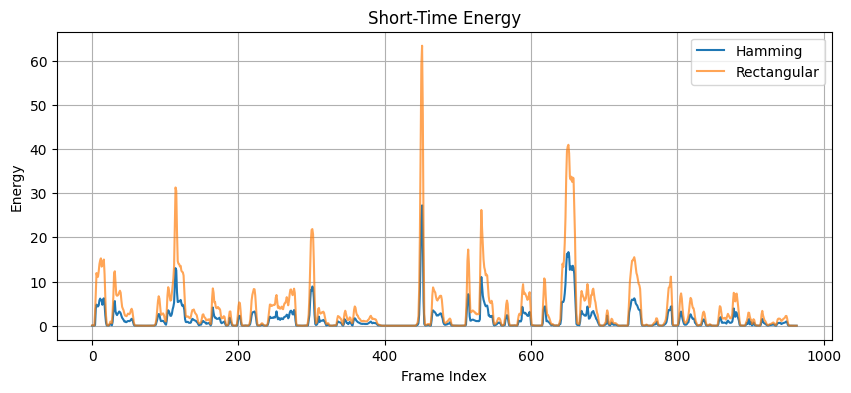

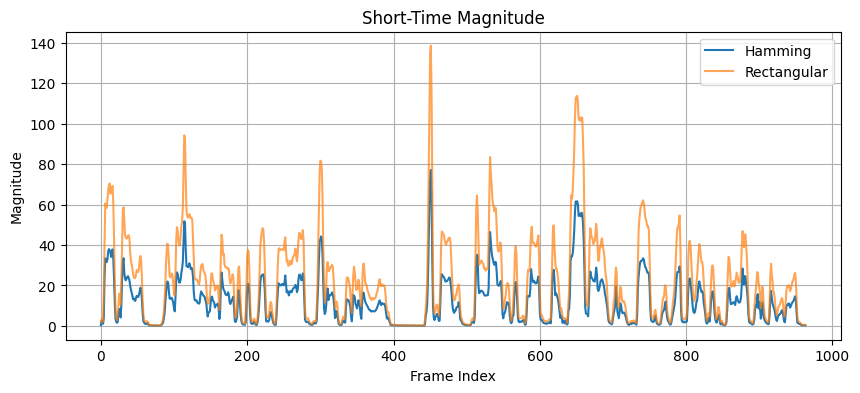

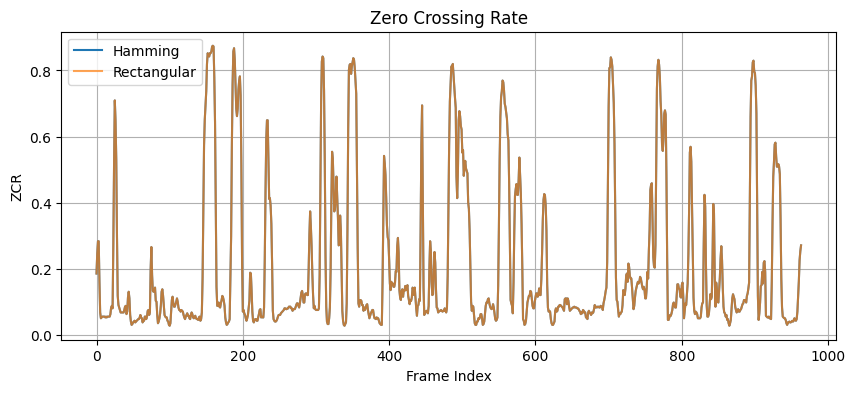

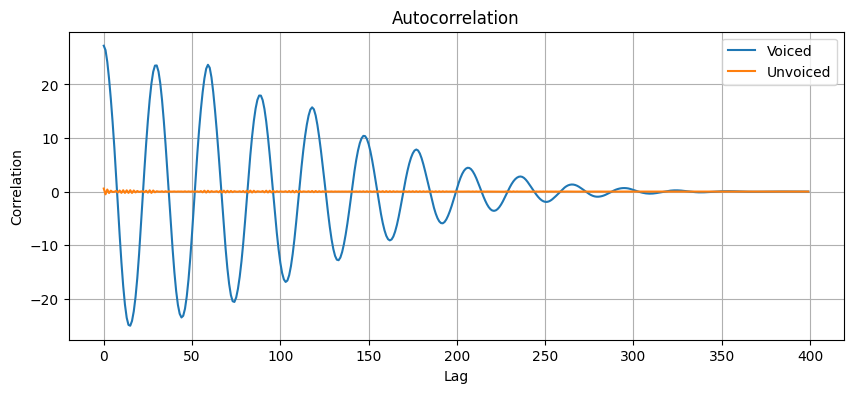

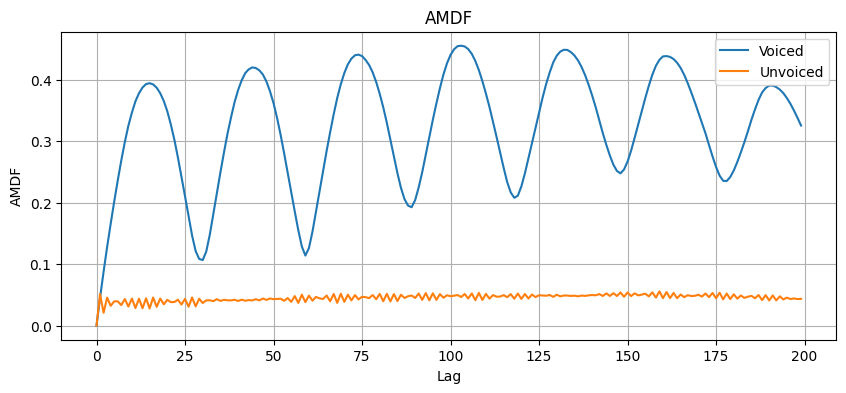

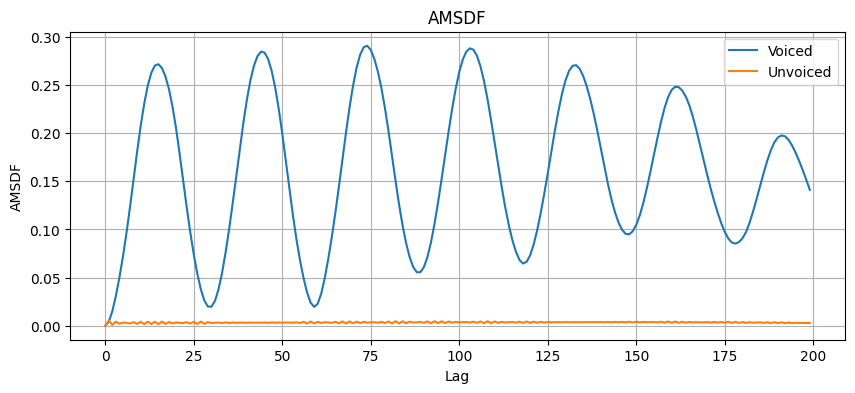


Estimated pitch period (samples): 1
Estimated pitch frequency (Hz): 16000.0


In [ ]:
# =========================================
# LAB ASSIGNMENT 4 — FULL IMPLEMENTATION
# =========================================

# !pip install librosa matplotlib numpy

import numpy as np
import librosa
import matplotlib.pyplot as plt

# =========================================
# 🔴 CHANGE FILE PATH
# =========================================
FILE = "/content/drive/MyDrive/Speech processing/LJ001-0001.wav"   # <-- put your wav file here
SR_TARGET = 16000

# =========================================
# 1️⃣ LOAD FIRST 20 SECONDS
# =========================================
x, sr = librosa.load(FILE, sr=SR_TARGET)
x = x[:20 * sr]

t = np.arange(len(x)) / sr

plt.figure(figsize=(12,4))
plt.plot(t, x)
plt.title("Waveform — First 20 seconds")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# =========================================
# 2️⃣ FRAME PARAMETERS
# =========================================
FRAME_MS = 25
SHIFT_MS = 10

frame_len = int(sr * FRAME_MS / 1000)
frame_shift = int(sr * SHIFT_MS / 1000)

num_frames = int((len(x) - frame_len) / frame_shift) + 1

print("Frame length:", frame_len)
print("Frame shift:", frame_shift)
print("Total frames:", num_frames)

# =========================================
# 3️⃣ FRAMING FUNCTION
# =========================================
def get_frames(signal):
    frames = []
    for i in range(num_frames):
        start = i * frame_shift
        frame = signal[start:start + frame_len]
        frames.append(frame)
    return np.array(frames)

frames = get_frames(x)

# =========================================
# 4️⃣ WINDOWS
# =========================================
hamming_win = np.hamming(frame_len)
rect_win = np.ones(frame_len)

frames_ham = frames * hamming_win
frames_rect = frames * rect_win

# =========================================
# 5️⃣ FEATURE FUNCTIONS
# =========================================
def short_time_energy(frame):
    return np.sum(frame**2)

def short_time_magnitude(frame):
    return np.sum(np.abs(frame))

def zero_crossing_rate(frame):
    return np.mean(np.abs(np.diff(np.sign(frame)))) / 2

def autocorrelation(frame):
    corr = np.correlate(frame, frame, mode='full')
    return corr[len(corr)//2:]

def amdf(frame, max_lag=200):
    N = len(frame)
    vals = []
    for k in range(max_lag):
        vals.append(np.mean(np.abs(frame[:N-k] - frame[k:N])))
    return np.array(vals)

def amsdf(frame, max_lag=200):
    N = len(frame)
    vals = []
    for k in range(max_lag):
        vals.append(np.mean((frame[:N-k] - frame[k:N])**2))
    return np.array(vals)

# =========================================
# 6️⃣ FRAME-WISE FEATURE EXTRACTION
# =========================================
def extract_features(frames):
    STE, STM, ZCR = [], [], []

    for frame in frames:
        STE.append(short_time_energy(frame))
        STM.append(short_time_magnitude(frame))
        ZCR.append(zero_crossing_rate(frame))

    return np.array(STE), np.array(STM), np.array(ZCR)

STE_h, STM_h, ZCR_h = extract_features(frames_ham)
STE_r, STM_r, ZCR_r = extract_features(frames_rect)

# =========================================
# 7️⃣ PLOT FEATURES (HAMMING vs RECTANGULAR)
# =========================================
def plot_feature(f_h, f_r, title, ylabel):
    plt.figure(figsize=(10,4))
    plt.plot(f_h, label="Hamming")
    plt.plot(f_r, label="Rectangular", alpha=0.7)
    plt.title(title)
    plt.xlabel("Frame Index")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid()
    plt.show()

plot_feature(STE_h, STM_r*0 + STE_r, "Short-Time Energy", "Energy")
plot_feature(STM_h, STM_r, "Short-Time Magnitude", "Magnitude")
plot_feature(ZCR_h, ZCR_r, "Zero Crossing Rate", "ZCR")

# =========================================
# 8️⃣ PERIODICITY ANALYSIS (Task-2)
# =========================================
# choose one voiced-like frame (high energy, low ZCR)
voiced_idx = np.argmax(STE_h)

# choose one unvoiced-like frame (high ZCR)
unvoiced_idx = np.argmax(ZCR_h)

voiced_frame = frames_ham[voiced_idx]
unvoiced_frame = frames_ham[unvoiced_idx]

# compute functions
ac_voiced = autocorrelation(voiced_frame)
ac_unvoiced = autocorrelation(unvoiced_frame)

amdf_voiced = amdf(voiced_frame)
amdf_unvoiced = amdf(unvoiced_frame)

amsdf_voiced = amsdf(voiced_frame)
amsdf_unvoiced = amsdf(unvoiced_frame)

# =========================================
# 9️⃣ PLOT PERIODICITY FUNCTIONS
# =========================================
plt.figure(figsize=(10,4))
plt.plot(ac_voiced, label="Voiced")
plt.plot(ac_unvoiced, label="Unvoiced")
plt.title("Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(amdf_voiced, label="Voiced")
plt.plot(amdf_unvoiced, label="Unvoiced")
plt.title("AMDF")
plt.xlabel("Lag")
plt.ylabel("AMDF")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(amsdf_voiced, label="Voiced")
plt.plot(amsdf_unvoiced, label="Unvoiced")
plt.title("AMSDF")
plt.xlabel("Lag")
plt.ylabel("AMSDF")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 🔟 PITCH ESTIMATION (Task-3)
# =========================================
# ignore zero lag
lag_range = ac_voiced[1:400]
pitch_lag = np.argmax(lag_range) + 1

pitch_freq = sr / pitch_lag

print("\nEstimated pitch period (samples):", pitch_lag)
print("Estimated pitch frequency (Hz):", pitch_freq)
